<a href="https://colab.research.google.com/github/sujitx-vs/PGCP-AI_PML/blob/main/Day8_PML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression,LogisticRegression

from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,r2_score,mean_squared_error

In [ ]:
df = pd.read_csv('/content/SNP.csv')

In [ ]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [ ]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


In [ ]:
df.isna().sum()

,0
Age,0
EstimatedSalary,0
Purchased,0


In [ ]:
df.duplicated().sum()

np.int64(33)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

<Axes: xlabel='Age', ylabel='Count'>

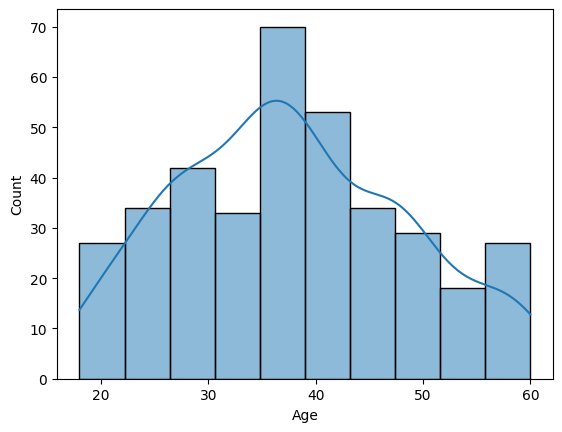

In [ ]:
sns.histplot(df['Age'],kde=True)

<Axes: xlabel='Purchased', ylabel='EstimatedSalary'>

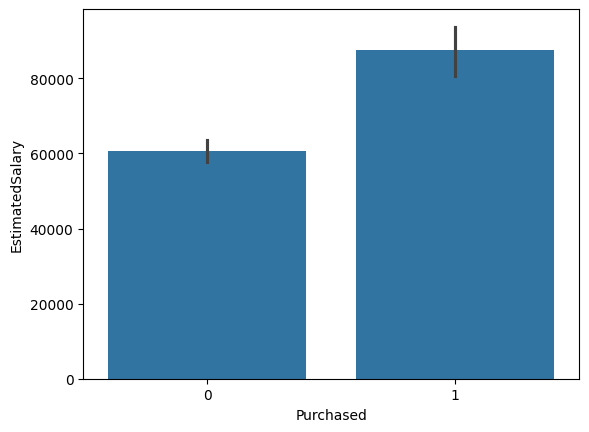

In [ ]:
sns.barplot(y='EstimatedSalary', x='Purchased', data=df)

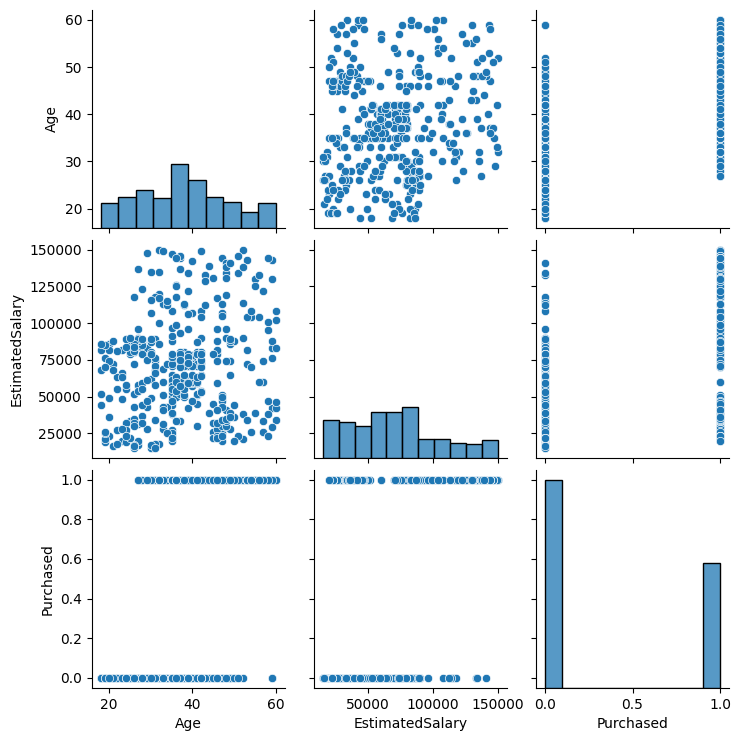

In [ ]:
sns.pairplot(df)

<Axes: >

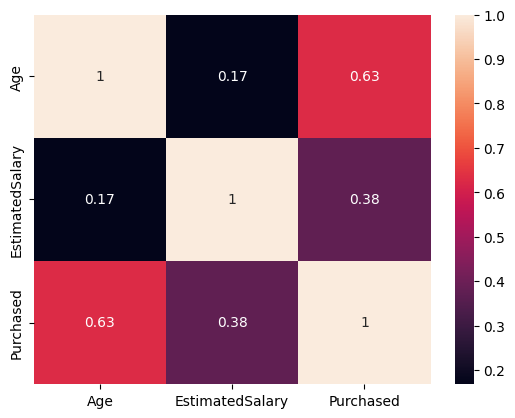

In [ ]:
sns.heatmap(df.corr(),annot=True)

In [ ]:
df['Age_Sal_ratio'] = df['Age']/df['EstimatedSalary']

In [ ]:
df.head()

,Age,EstimatedSalary,Purchased,Age_Sal_ratio
0,19,19000,0,0.001000
1,35,20000,0,0.001750
2,26,43000,0,0.000605
3,27,57000,0,0.000474
4,19,76000,0,0.000250


In [ ]:
X = df.drop('Purchased',axis = 1)

In [ ]:
Y = df['Purchased']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=.2,random_state=0)

In [ ]:
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.fit_transform(x_test)

In [ ]:
lg = LogisticRegression()

In [ ]:
lg.fit(x_train,y_train)

LogisticRegression()

In [ ]:
ypred_lg = lg.predict(x_test)

In [ ]:
accuracy_score(y_test,ypred_lg)

0.8513513513513513

In [ ]:
confusion_matrix(y_test,ypred_lg)

array([[44,  3],
       [ 8, 19]])

# Desicion Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
model = DecisionTreeClassifier(criterion='entropy',max_depth=5,random_state=0)
reg_model = DecisionTreeRegressor(max_depth=5,random_state=0)

In [ ]:
reg_model.fit(x_train,y_train)
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [ ]:
y_pred = model.predict(x_test)
y_pred_reg = reg_model.predict(x_test)

In [ ]:
r2_score(y_test,y_pred_reg)

0.6885376723190224

In [ ]:
mean_squared_error(y_test,y_pred_reg)

0.07217781114447781

In [ ]:
confusion_matrix(y_test,y_pred)

array([[39,  8],
       [ 6, 21]])

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.83      0.85        47
           1       0.72      0.78      0.75        27

    accuracy                           0.81        74
   macro avg       0.80      0.80      0.80        74
weighted avg       0.81      0.81      0.81        74



In [ ]:
accuracy_score(y_test,y_pred)

0.8108108108108109

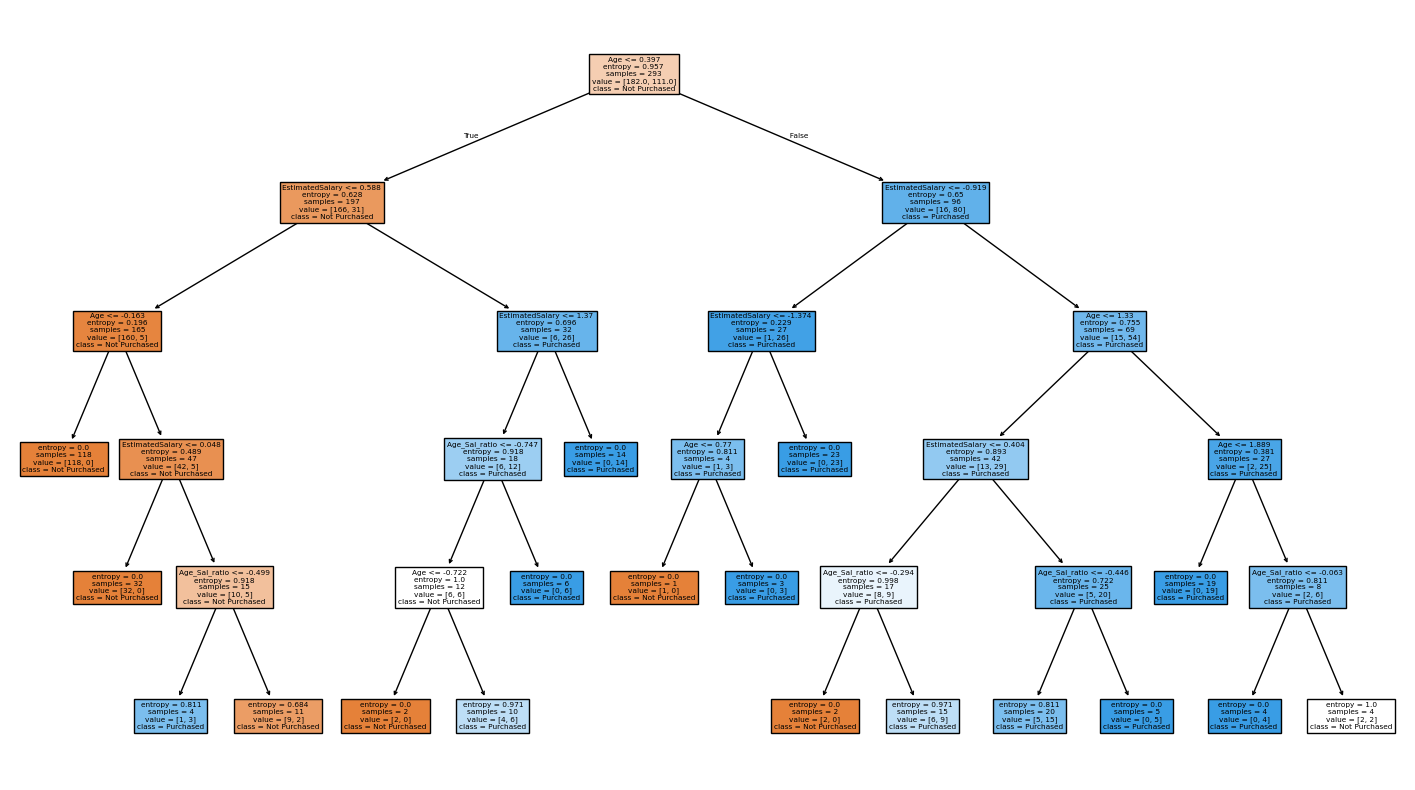

In [ ]:
from sklearn import tree
plt.figure(figsize=(18,10))
tree.plot_tree(model,feature_names=['Age','EstimatedSalary','Age_Sal_ratio'],class_names=["Not Purchased","Purchased"],filled = True)

plt.show()


# iris

In [ ]:
data = pd.read_csv('/content/Iris (1).csv')

In [ ]:
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [ ]:
data.describe()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [ ]:
data.isna().sum()

,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [ ]:
data.duplicated().sum()

np.int64(3)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
data.duplicated().sum()

np.int64(0)

In [ ]:
data.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
X = data.iloc[:,:-1]
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
Y = data.iloc[:,-1:]
Y.head()

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X,Y,test_size=.2,random_state=45)

In [ ]:
model.fit(x_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=0)

In [ ]:
y_pred = model.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred)

0.9666666666666667

In [ ]:
confusion_matrix(y_test,y_pred)

array([[ 8,  0,  0],
       [ 0, 11,  0],
       [ 0,  1, 10]])

In [ ]:
print(classification_report(y_test,y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       0.92      1.00      0.96        11
 Iris-virginica       1.00      0.91      0.95        11

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

